In [73]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table, vstack
from dataclasses import replace
from scipy.ndimage import gaussian_filter1d
from astropy.stats import biweight_location
import importlib
import datetime as _dt
from astropy.io import fits
import os

import run_config
import utils_lya_halo

from run_config import cfg, smoke
from utils_lya_halo import read_galaxy_fits, measure, multicat, plotting, analysis, stack, core, io
from utils_lya_halo.extract import build_run_table, build_bad_fiber_mask
from utils_lya_halo import PipelineConfig

from utils_lya_halo.stack import (convert_avg_fiber_bin, stack_spec_values, coadd_galaxies, rest_grid)

import warnings
from astropy.utils.exceptions import AstropyUserWarning

# with warnings.catch_warnings():
#     warnings.simplefilter("ignore", AstropyUserWarning)
#     res = stack.build_core_stacks(cfg2, prod, mask=clean, output="flux")

In [25]:
N = None
core_radius = 3.5 #Arcsec
#catalog_path = "catalogs/lya_halo_catalog_cuts/lya_mosdef_catalog_KEEP.fits"
catalog_path="catalogs/lya_halo_catalog_cuts/ALL_haoiii_sn5_mosdef_catalog.txt",
field = "BOTH"

LYA_REST = 1215.67
cfg2 = replace(cfg, 
    num_gal         = N,
    field           = field,
    catalog         = "MOSDEF",
    catalog_path    = catalog_path,
    bins      = [0, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
    bin_mode  = "virial",
    mask_method     = "image",
    mask_percentile = 90,
    bg_inner_arcsec = 57.0,
    bg_outer_arcsec = 63.0,
    min_bg_fibers   = 25,
    smooth_bg       = True,
    smoothing_values = [200, 20, 300],
    fiber_combine_method   = "biweight",
    rest_delta      = 0.2,
    rest_wave_min   = 1100,
    rest_wave_max   = 1700,
    rest_density    = True,
    cut_radial_bin  = 5,
    min_good_wave   = 100,
    combine_wave_block = 32,
    line_window = [LYA_REST-4, LYA_REST+4],
    n_bootstrap = 500)

In [60]:
catalog_keep = Table.read('catalogs/lya_halo_catalog_cuts/lya_mosdef_catalog_KEEP.fits', format='fits')

prod_egs    = core.read_core_fits("6-23-26-core_extraction_egs_MF.fits")
prod_cosmos = core.read_core_fits("6-23-26-core_extraction_cosmos_MF.fits")

core_prod = stack.concat_core_prods(prod_egs, prod_cosmos)
print(f"pooled {core_prod['n_per_input']} -> {len(core_prod['core_spec'])} galaxies")

mask_clean = core_prod['catalog']['CLEAN']
stacks_gal = core.build_core_stacks(cfg2, core_prod, mask=mask_clean, output="flux")

pooled [244, 278] -> 522 galaxies


In [27]:
product1 = io.read_galaxy_fits('./outputs/galaxy_catc1488c_b8_8c91de_AEGIS_MOSDEF_virial_biweight_image_bg57-63.fits')
product1 = io.apply_finite_cut(product1, cfg2.cut_radial_bin, cfg2.min_good_wave)

#product2 = read_galaxy_fits('./outputs/galaxy_cat6dc9dc_b11_e708b2_COSMOS_3DHST_kpc_biweight_image_bg57-63.fits')
product2 = io.read_galaxy_fits('./outputs/galaxy_catc1488c_b8_8c91de_COSMOS_MOSDEF_virial_biweight_image_bg57-63.fits')
product2 = io.apply_finite_cut(product2, cfg2.cut_radial_bin, cfg2.min_good_wave)

# combine into one product -- tags each galaxy with its source in column "SUBSET"
halo_prod = multicat.combine_products(
    {"cat1": product1, "cat2": product2},
    label_col="SUBSET")

Finite-spectrum cut (bin 5, > 100 px): kept 224 / 248 galaxies
Finite-spectrum cut (bin 5, > 100 px): kept 275 / 280 galaxies
combined 2 products -> 499 galaxies (origin in column 'SUBSET')


In [33]:
from utils_lya_halo.io import GalaxyProduct
from utils_lya_halo.stack import build_stacks
from utils_lya_halo.measure import flux_weighted_centroid, C_KMS
from utils_lya_halo.measure import measure_centroid


def lya_zobs_from_offset(z_sys, v_offset_kms):
    """1 + z_obs = (1 + z_sys)(1 + v_offset/c)."""
    z_sys = np.asarray(z_sys, float); v = np.asarray(v_offset_kms, float)
    return (1.0 + z_sys) * (1.0 + v / C_KMS) - 1.0


def _subset_product(product, mask, z_new=None, z_col="Z"):
    """Slice every galaxy-axis array + catalog by `mask`; optionally swap z."""
    mask = np.asarray(mask, bool)
    cat = product.catalog[mask].copy()
    if z_new is not None:
        cat[z_col] = np.asarray(z_new, float)
    nfib = product.nfib[mask] if product.nfib is not None else None
    bg = product.background[mask] if product.background is not None else None
    return GalaxyProduct(spec=product.spec[mask], err=product.err[mask], nfib=nfib,
                         wave=product.wave, r_edges=product.r_edges, catalog=cat,
                         header=product.header, background=bg)


def _as_float(col):
    """Catalog column -> float ndarray, masked entries -> NaN."""
    if hasattr(col, "filled"):
        col = col.filled(np.nan)
    return np.asarray(col, float)


def _haversine_arcsec(ra0, dec0, ra, dec):
    r0, d0 = np.radians(ra0), np.radians(dec0)
    r, d = np.radians(ra), np.radians(dec)
    a = np.sin((d - d0) / 2) ** 2 + np.cos(d0) * np.cos(d) * np.sin((r - r0) / 2) ** 2
    return np.degrees(2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))) * 3600.0


def match_voffset_by_coords(halo_prod, core_prod, tol_arcsec=1.0,
                            ra_col="RA", dec_col="DEC", voff_key="v_offset"):
    """
    For each halo galaxy, find the nearest core galaxy (that has a finite
    Gaussian v_offset) within tol_arcsec and inherit its v_offset. Returns a
    (ngal_halo,) array, NaN where unmatched.
    """
    hcat, ccat = halo_prod.catalog, core_prod["catalog"]
    h_ra, h_dec = _as_float(hcat[ra_col]), _as_float(hcat[dec_col])
    c_ra, c_dec = _as_float(ccat[ra_col]), _as_float(ccat[dec_col])
    voff_core = np.asarray(core_prod["results"][voff_key], float)

    cand = np.isfinite(voff_core) & np.isfinite(c_ra) & np.isfinite(c_dec)
    ci = np.flatnonzero(cand)
    out = np.full(len(hcat), np.nan)
    seps = []
    n = 0
    for i in range(len(hcat)):
        if not (np.isfinite(h_ra[i]) and np.isfinite(h_dec[i])):
            continue
        sep = _haversine_arcsec(h_ra[i], h_dec[i], c_ra[ci], c_dec[ci])
        j = int(np.argmin(sep))
        seps.append(sep[j])
        if sep[j] <= tol_arcsec:
            out[i] = voff_core[ci[j]]; n += 1
    seps = np.asarray(seps)
    print(f"[coord-match] {n}/{len(hcat)} halo galaxies matched within "
          f"{tol_arcsec}\"  (nearest-neighbor median sep "
          f"{np.nanmedian(seps):.3f}\", 90th pct {np.nanpercentile(seps, 90):.3f}\")")
    return out


def build_dual_frame_products(halo_prod, core_prod, config, tol_arcsec=1.0,
                              ra_col="RA", dec_col="DEC", voff_key="v_offset"):
    zc = config.z_col
    cat = halo_prod.catalog
    voff = match_voffset_by_coords(halo_prod, core_prod, tol_arcsec,
                                   ra_col, dec_col, voff_key)
    z_sys = _as_float(cat[zc])
    ok = np.isfinite(voff) & np.isfinite(z_sys)
    print(f"[dual-frame] {int(ok.sum())} galaxies in the matched subsample")
    z_obs = lya_zobs_from_offset(z_sys[ok], voff[ok])
    return (_subset_product(halo_prod, ok, z_new=None,  z_col=zc),
            _subset_product(halo_prod, ok, z_new=z_obs, z_col=zc), ok, voff)


def frame_centroids(stacks, config, stack_method=None,
                    centroid_method=None, clip_negative=None):
    """
    Lyα centroid velocity per radial bin, using the SAME estimator, continuum,
    window, and coadd as the headline pipeline — all pulled from `config`:

        coadd          config.measure_stack_method     ('biweight')
        estimator      config.centroid_method          ('median50' = flux_median)
        clip_negative  config.clip_negative            (ignored by median50)
        window         config.line_window
        continuum      config.cont_bounds / cont_method / cont_order
        zero-velocity  config.LYA_REST

    Any of the three can be overridden for a robustness check, but the defaults
    ARE the config so the dual frame stays locked to the headline.
    """
    sm   = stack_method     or config.measure_stack_method
    cm   = centroid_method  or config.centroid_method
    clip = config.clip_negative if clip_negative is None else clip_negative

    rw     = np.asarray(stacks["rest_wave"], float)
    sf     = stacks["stacks"][sm]["flux"]
    bounds = tuple(config.line_window)

    v = np.full(sf.shape[0], np.nan)
    for r in range(sf.shape[0]):
        res = measure_centroid(
            rw, sf[r], method=cm, clip_negative=clip,
            bounds=bounds, cont_bounds=config.cont_bounds,
            lya_center=config.LYA_REST,
            cont_method=config.cont_method, cont_order=config.cont_order,
        )
        v[r] = res["centroid_vel_kms"]
    return v


def plot_frame_compare(stacks_sys, stacks_obs, config,
                       rvir_kpc=None, figsize=(9.0, 5.0), title=None):
    v_sys = frame_centroids(stacks_sys, config)   # estimator/continuum from cfg
    v_obs = frame_centroids(stacks_obs, config)
    edges = np.asarray(stacks_sys["r_edges"], float)
    r_mid = np.sqrt(edges[:-1] * edges[1:])
    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(0, color="0.6", lw=1, ls="--")
    ax.plot(r_mid, v_sys, "o-", color="tab:blue", lw=1.5, ms=6,
            label=r"systemic frame ($z_{\rm sys}$)")
    ax.plot(r_mid, v_obs, "s-", color="tab:red", lw=1.5, ms=6,
            label=r"Ly$\alpha$-peak frame ($z_{\rm obs}$)")
    if rvir_kpc:
        ax.axvline(rvir_kpc, color="0.5", lw=1, ls=":")
    ax.set_xlim(0.02, 30)
    ax.set_xscale("log"); ax.set_xlabel("Radius [VR]")
    ax.set_ylabel(r"$v_{\rm Ly\alpha}$ centroid [km s$^{-1}$]")
    ax.set_title(title or r"Centroid vs radius — systemic vs Ly$\alpha$-peak frame")
    ax.legend(frameon=False, fontsize=9); ax.grid(alpha=0.15, which="both")
    fig.tight_layout(); plt.show()
    return fig, ax, v_sys, v_obs


from utils_lya_halo.plotting import (
    _setup_radius_axis, _resolve_bin_mode, _get_vr_biweight_v)


def plot_frame_compare_boot(boot_sys, boot_obs, config,
                            vr_ticks=(0.1, 0.2, 0.5, 1, 2, 5, 10, 20),
                            ylims=(-300, 300), xlims=(0.03, 30), dx=1.04,
                            figsize=(8, 5), title=None,
                            save_fig=False, savename="Figure_dual_frame.png"):
    """
    Systemic- vs Lyα-peak-frame centroid profiles, each with its bootstrap
    16/84 band, on the SAME native radius axis as the headline (config.bin_mode:
    virial -> R/Rvir bottom + kpc top). Uses plotting._setup_radius_axis, so the
    innermost bin (edge 0) is placed at the arithmetic midpoint instead of
    vanishing on the log axis. `dx` slightly offsets the red points in x so the
    two error bars don't sit on top of each other.
    """
    bin_mode = _resolve_bin_mode(config.bin_mode, boot_sys)
    # kpc<->R/Rvir uses the REAL systemic virial radius (z_obs is a fictitious
    # alignment redshift; the physical Rvir must come from z_sys).
    VR = _get_vr_biweight_v(None, boot_sys)
    r_edges = np.asarray(boot_sys["r_edges"], float)

    fig, ax = plt.subplots(figsize=figsize)
    r_mid, xerr = _setup_radius_axis(ax, r_edges, bin_mode, VR, None,
                                     vr_ticks, xlims)
    ax.axhline(0, color="0.6", lw=1, ls="--")

    for boot, xfac, color, mk, lab in [
        (boot_sys, 1/dx, "tab:blue", "o", r"systemic frame ($z_{\rm sys}$)"),
        (boot_obs, dx,   "tab:red",  "s", r"Ly$\alpha$-peak frame ($z_{\rm obs}$)")]:
        v  = np.asarray(boot["centroid_v_med"])
        lo = np.asarray(boot["centroid_v_lo"])
        hi = np.asarray(boot["centroid_v_hi"])
        ax.errorbar(r_mid * xfac, v, yerr=np.vstack([v - lo, hi - v]),
                    fmt=mk, capsize=3.5, ms=6, lw=1.5, color=color, label=lab)

    if ylims:
        ax.set_ylim(ylims)
    ax.set_ylabel(r"$v_{\rm Ly\alpha}$ centroid [km s$^{-1}$]")
    ax.set_title(title or r"Ly$\alpha$ centroid vs. radius — dual frame")
    ax.legend(frameon=False, fontsize=9, loc="best")
    if save_fig:
        plt.savefig(savename, dpi=300, bbox_inches="tight")
    plt.show()
    return fig, ax

In [30]:
prod_sys, prod_obs, ok, voff = build_dual_frame_products(
    halo_prod, core_prod, cfg2, tol_arcsec=0.5)

# cube needed for the bootstrap -> keep_cube=True
stacks_sys = build_stacks(cfg2, prod_sys, keep_cube=True)
stacks_obs = build_stacks(cfg2, prod_obs, keep_cube=True)

[coord-match] 209/499 halo galaxies matched within 0.5"  (nearest-neighbor median sep 15.284", 90th pct 55.593")
[dual-frame] 209 galaxies in the matched subsample


Capping logMstar 11.01 -> 11.00, z=2.296
Capping logMstar 11.34 -> 11.00, z=2.297
Capping logMstar 11.34 -> 11.00, z=2.297
Capping logMstar 11.07 -> 11.00, z=2.475
Capping logMstar 11.29 -> 11.00, z=2.191
Capping logMstar 11.74 -> 11.00, z=2.447
Capping logMstar 11.06 -> 11.00, z=2.472
Capping logMstar 11.06 -> 11.00, z=2.479
Capping logMstar 11.63 -> 11.00, z=2.487


Capping logMstar 11.01 -> 11.00, z=2.297
Capping logMstar 11.34 -> 11.00, z=2.304
Capping logMstar 11.34 -> 11.00, z=2.304
Capping logMstar 11.07 -> 11.00, z=2.477
Capping logMstar 11.29 -> 11.00, z=2.190
Capping logMstar 11.74 -> 11.00, z=2.454
Capping logMstar 11.06 -> 11.00, z=2.477
Capping logMstar 11.06 -> 11.00, z=2.476
Capping logMstar 11.63 -> 11.00, z=2.486


In [31]:
# headline Stage-3 bootstrap on each frame (estimator/continuum from cfg2)
boot_sys = analysis.run_measurement_suite(cfg2, stacks_sys)
boot_obs = analysis.run_measurement_suite(cfg2, stacks_obs)

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


line moments (fiducial stack, no bootstrap):
  0-0.1: v=+206.8  σ=319.0  skew=-0.396
  0.1-0.2: v=+154.7  σ=343.2  skew=-0.430
  0.2-0.5: v=-24.3  σ=375.2  skew=-0.241
  0.5-1: v=+41.6  σ=278.1  skew=+0.023
  1-2: v=+50.6  σ=250.5  skew=+0.458
  2-5: v=+29.3  σ=255.6  skew=-0.552
  5-10: v=-122.4  σ=309.2  skew=-0.844
  10-20: v=+49.3  σ=313.6  skew=-0.297


  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


line moments (fiducial stack, no bootstrap):
  0-0.1: v=+29.5  σ=299.1  skew=-0.039
  0.1-0.2: v=+3.9  σ=300.5  skew=-0.298
  0.2-0.5: v=-145.4  σ=368.5  skew=-0.270
  0.5-1: v=-117.6  σ=322.5  skew=+0.172
  1-2: v=-139.3  σ=241.2  skew=-0.364
  2-5: v=-213.8  σ=288.9  skew=-0.310
  5-10: v=-246.1  σ=281.0  skew=+0.126
  10-20: v=-115.2  σ=355.4  skew=+0.464


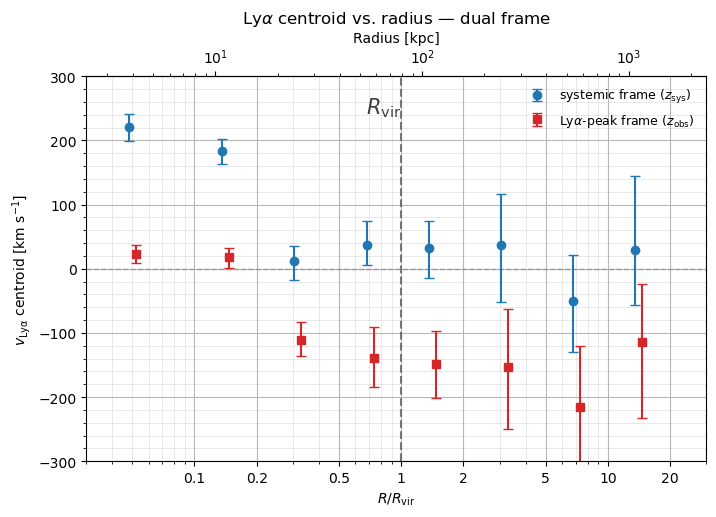

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Ly$\\alpha$ centroid vs. radius — dual frame'}, xlabel='$R/R_{\\rm vir}$', ylabel='$v_{\\rm Ly\\alpha}$ centroid [km s$^{-1}$]'>)

In [34]:
# dual-frame figure with bands, headline radius axis (inner bin now visible)
plot_frame_compare_boot(boot_sys, boot_obs, cfg2, ylims=(-300, 300))

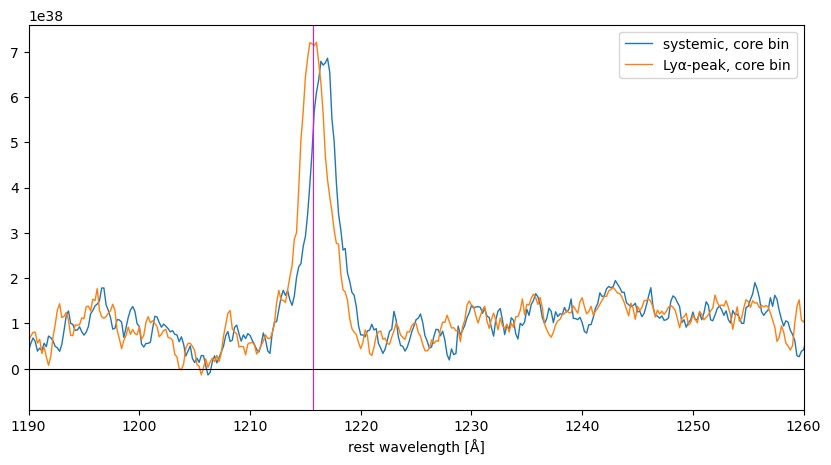

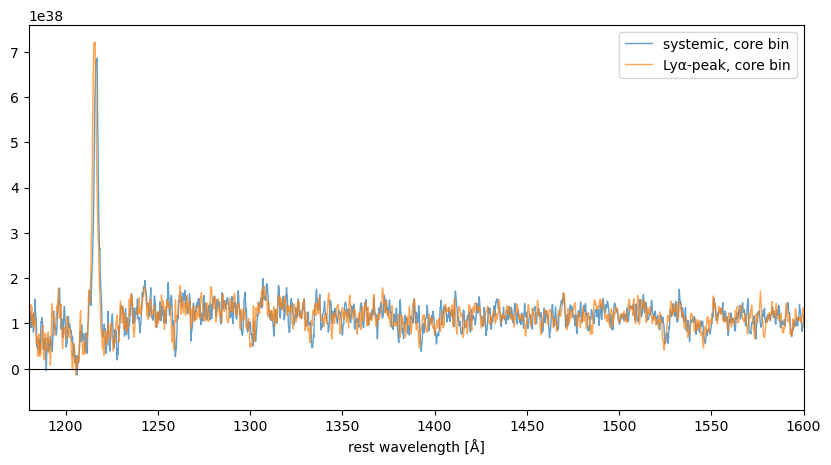

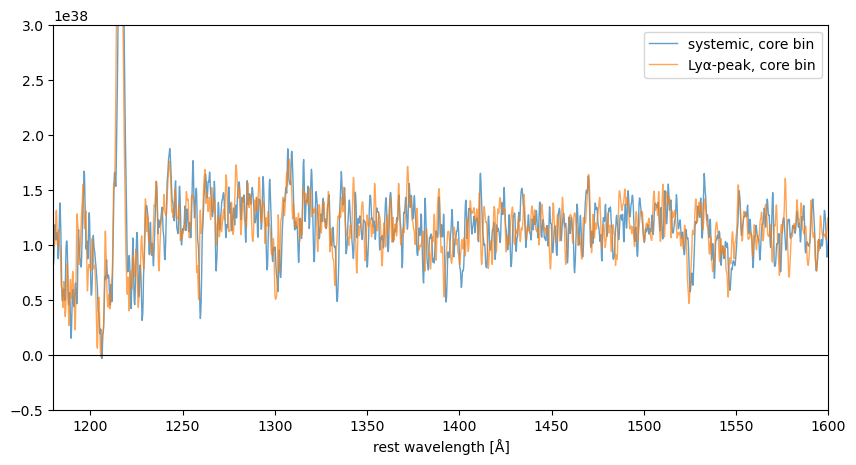

In [41]:
rw = stacks_sys["rest_wave"]
plt.figure(figsize=(10, 5))
plt.plot(rw, stacks_sys["stacks"]["biweight"]["flux"][0], label="systemic, core bin", lw=1)
plt.plot(rw, stacks_obs["stacks"]["biweight"]["flux"][0], label="Lyα-peak, core bin", lw=1)
plt.axvline(1215.67, color="magenta", lw=0.8); plt.axhline(0, c="k", lw=0.8)
plt.xlim(1190, 1260); plt.xlabel("rest wavelength [Å]"); plt.legend(); plt.show()

plt.figure(figsize=(10, 5))
plt.plot(rw, stacks_sys["stacks"]["biweight"]["flux"][0], label="systemic, core bin", lw=1, alpha=0.7)
plt.plot(rw, stacks_obs["stacks"]["biweight"]["flux"][0], label="Lyα-peak, core bin", lw=1, alpha=0.7)
plt.axhline(0, c="k", lw=0.8); plt.xlim(1180, 1600)
plt.xlabel("rest wavelength [Å]"); plt.legend(); plt.show()

plt.figure(figsize=(10, 5))
plt.plot(rw, gaussian_filter1d(stacks_sys["stacks"]["biweight"]["flux"][0], 1), label="systemic, core bin", lw=1, alpha=0.7)
plt.plot(rw, gaussian_filter1d(stacks_obs["stacks"]["biweight"]["flux"][0], 1), label="Lyα-peak, core bin", lw=1, alpha=0.7)
plt.axhline(0, c="k", lw=0.8); plt.xlim(1180, 1600); plt.ylim(-0.5e38, 3e38)
plt.xlabel("rest wavelength [Å]"); plt.legend(); plt.show()

# Composite Spread of Single Galaxy

In [109]:
def vshift_broadening_floor(rest_wave, intrinsic_profile, v_offsets_kms,
                            lya_center=1215.67, stack_method="biweight"):
    """
    Forward-model the broadening FLOOR a velocity-offset distribution imposes
    on a stack, assuming every galaxy has the SAME intrinsic profile and differs
    ONLY by a bulk velocity shift. The output is the stacked profile you'd get
    from pure v_offset scatter -- the null against which a 'real' double peak
    must be distinguished.

    rest_wave         : (nwave,) rest-frame grid [A]
    intrinsic_profile : (nwave,) one assumed per-galaxy line shape (already LSF-
                        convolved, i.e. an observed single-galaxy profile)
    v_offsets_kms     : (ngal,) the per-galaxy velocity offsets to inject [km/s]
    Returns dict: stacked (nwave,), and FWHM-ish width proxies for input vs stack.
    """
    c = 299792.458
    wave = np.asarray(rest_wave, float)
    prof = np.asarray(intrinsic_profile, float)
    shifts = np.asarray(v_offsets_kms, float)

    # shift each galaxy by interpolating the profile onto a v-offset grid
    cube = np.empty((shifts.size, wave.size))
    for i, dv in enumerate(shifts):
        lam_shift = wave * (1.0 - dv / c)          # observe-frame shift of the line
        cube[i] = np.interp(wave, lam_shift, prof, left=0.0, right=0.0)

    if stack_method == "median":
        stacked = np.nanmedian(cube, axis=0)
    else:
        stacked = biweight_location(cube, axis=0, ignore_nan=True)

    def _fwhm_kms(w, f):
        f = f - np.nanmin(f)
        half = 0.5 * np.nanmax(f)
        above = w[f >= half]
        if above.size < 2:
            return np.nan
        return (above.max() - above.min()) / lya_center * c

    return {
        "stacked": stacked,
        "fwhm_intrinsic_kms": _fwhm_kms(wave, prof),
        "fwhm_stacked_kms": _fwhm_kms(wave, stacked),
        "vscatter_std_kms": float(np.nanstd(shifts)),
    }



def double_peak_excess(rest_wave, observed_stack, null_stack,
                       lya_center=1215.67, win=(1209, 1223)):
    """
    Compare an OBSERVED stacked Lya profile to a pure-vscatter NULL stack and
    return a 'double-peakedness excess': how much more bimodal the real stack is
    than scatter alone predicts. >0 means structure beyond what v_offset
    smearing explains.

    Uses a simple trough-to-peak contrast: (mean of two highest local maxima
    minus central minimum) / mean peak, measured on each profile in the window.
    """
    wave = np.asarray(rest_wave, float)
    m = (wave >= win[0]) & (wave <= win[1])
    w = wave[m]

    def _contrast(f):
        f = np.asarray(f, float)[m]
        f = f - np.nanmin(f)
        if np.nanmax(f) <= 0:
            return np.nan
        # central minimum near line center, peaks on either side
        ic = np.argmin(np.abs(w - lya_center))
        blue_pk = np.nanmax(f[:ic]) if ic > 0 else np.nan
        red_pk  = np.nanmax(f[ic:]) if ic < f.size else np.nan
        trough  = f[ic]
        peak_mean = np.nanmean([blue_pk, red_pk])
        
        return (peak_mean - trough) / peak_mean if peak_mean > 0 else np.nan

    c_obs = _contrast(observed_stack)
    c_null = _contrast(null_stack)
    return {"contrast_observed": c_obs,
            "contrast_null": c_null,
            "double_peak_excess": c_obs - c_null}

v scatter std : 280.25914444346125 km/s


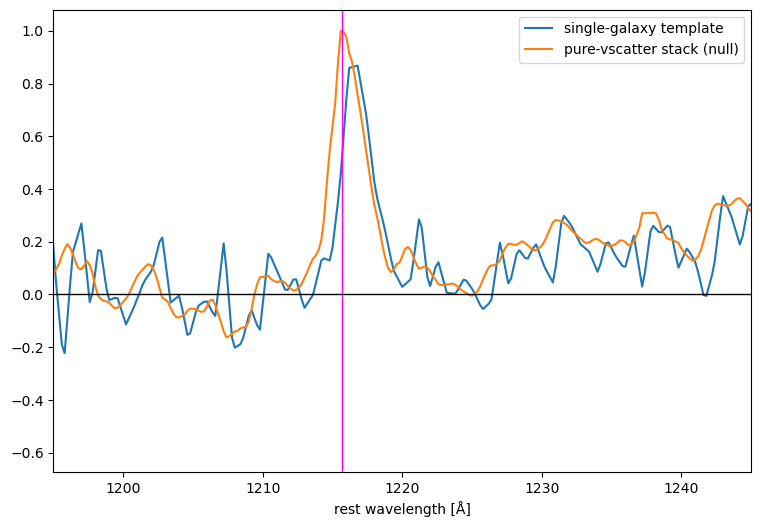

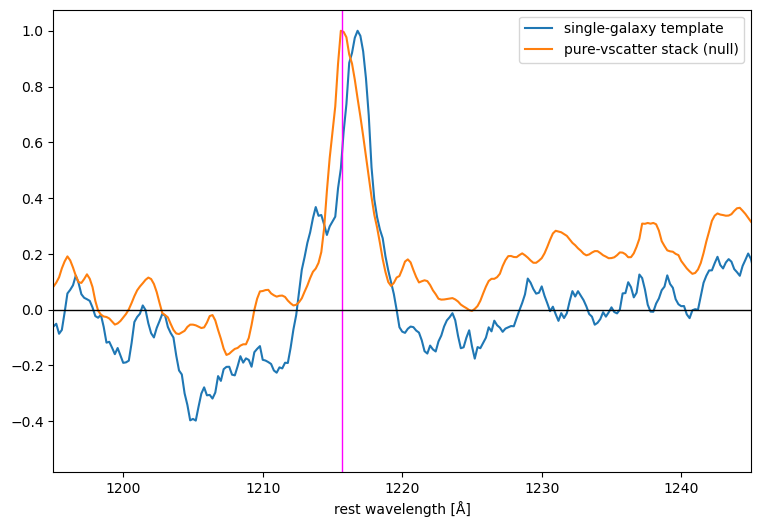

observed trough/peak contrast : 0.225
null (vscatter) contrast      : -0.057
double-peak EXCESS            : +0.282


In [113]:
# one bright galaxy's observed Lya profile as the 'intrinsic' template
template = stacks_gal['cube_flux'][2]        # (nwave,) from your Stage-2 cube
voff = core_prod['results']['v_offset'][mask_clean]     # (ngal,) e.g. red-peak minus z_sys

out = vshift_broadening_floor(stacks_gal["rest_wave"], template, voff)

print(f"v scatter std : {out['vscatter_std_kms']} km/s")

plt.figure(figsize=(9, 6))
plt.plot(stacks_gal["rest_wave"], template/np.nanmax(template), label="single-galaxy template")
plt.plot(stacks_gal["rest_wave"], out["stacked"]/np.nanmax(out["stacked"]),
         label="pure-vscatter stack (null)")
plt.axvline(1215.67, color="magenta", lw=1); plt.axhline(0, c='k', lw=1)
plt.xlim(1195, 1245); plt.xlabel("rest wavelength [Å]"); plt.legend()
plt.show()

# Another comparison

plt.figure(figsize=(9, 6))
plt.plot(stacks_gal["rest_wave"], stacks_gal["stacks"]["biweight"]["flux"]/np.nanmax(stacks_gal["stacks"]["biweight"]["flux"]), label="single-galaxy template")
plt.plot(stacks_gal["rest_wave"], out["stacked"]/np.nanmax(out["stacked"]),
         label="pure-vscatter stack (null)")
plt.axvline(1215.67, color="magenta", lw=1); plt.axhline(0, c='k', lw=1)
plt.xlim(1195, 1245); plt.xlabel("rest wavelength [Å]"); plt.legend()
plt.show()

res = double_peak_excess(stacks["rest_wave"],
                         observed_stack=stacks_gal["stacks"]["biweight"]["flux"],  # core bin
                         null_stack=out["stacked"])

print(f"observed trough/peak contrast : {res['contrast_observed']:.3f}")
print(f"null (vscatter) contrast      : {res['contrast_null']:.3f}")
print(f"double-peak EXCESS            : {res['double_peak_excess']:+.3f}")
# excess ~0  -> blending is consistent with pure v_offset scatter (can't claim RT)
# excess >0  -> real bimodality beyond scatter; defensible as physical structure

In [114]:
import numpy as np
from astropy.stats import biweight_location

def two_population_null(rest_wave, template, v_blue_kms, v_red_kms,
                        frac_blue=0.5, ngal=400, sigma_within_kms=80.0,
                        lya_center=1215.67, stack_method="biweight", seed=1):
    """
    Build the COMPILATION null: a population of SINGLE-peaked galaxies split into
    a blue-peaking group (fraction frac_blue, centered at v_blue_kms) and a
    red-peaking group (centered at v_red_kms), each with intra-group scatter
    sigma_within_kms. This is the degeneracy your one-template null can't probe:
    it produces a bimodal stack from purely single-peaked members.

    template : (nwave,) a SINGLE-peaked per-galaxy profile (LSF-convolved).
               Its own peak is taken as the zero-point and re-shifted.
    Returns the stacked compilation profile on rest_wave.
    """
    c = 299792.458
    wave = np.asarray(rest_wave, float)
    prof = np.asarray(template, float)
    rng = np.random.default_rng(seed)

    # re-center the template so its peak is at lya_center before re-shifting
    pk_lam = wave[np.nanargmax(prof)]
    v0 = (pk_lam - lya_center) / lya_center * c
    base_v = -v0  # shift that moves template peak to line center

    n_blue = int(round(frac_blue * ngal))
    centers = np.concatenate([
        np.full(n_blue, v_blue_kms),
        np.full(ngal - n_blue, v_red_kms),
    ])
    draws = centers + rng.normal(0.0, sigma_within_kms, size=ngal) + base_v

    cube = np.empty((ngal, wave.size))
    for i, dv in enumerate(draws):
        lam_shift = wave * (1.0 - dv / c)
        cube[i] = np.interp(wave, lam_shift, prof, left=0.0, right=0.0)

    if stack_method == "median":
        stacked = np.nanmedian(cube, axis=0)
    else:
        stacked = biweight_location(cube, axis=0, ignore_nan=True)
    return stacked